# Posterior Calibration of Diffusion-Based Inverse Solvers (1D Gaussian)

**Prior:** $x \sim \mathcal{N}(\mu_0, \sigma_0^2)$ · **Forward model:** $y = x + n$, $n \sim \mathcal{N}(0, \sigma_n^2)$

**Analytic posterior:** $p(x|y) = \mathcal{N}\!\left(\sigma_{\text{post}}^2 \left(\frac{y}{\sigma_n^2} + \frac{\mu_0}{\sigma_0^2}\right),\; \sigma_{\text{post}}^2\right)$ where $\sigma_{\text{post}}^2 = \frac{\sigma_0^2 \sigma_n^2}{\sigma_0^2 + \sigma_n^2}$

We compare four methods: **Vanilla LATINO**, **DPS**, **MMPS**, and **LATINO + SDE**.

In [9]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

In [10]:
# Problem setup
mu_0 = 0.0       # prior mean
sigma_0 = 1.0    # prior std
sigma_n = 0.5    # observation noise std
y_star = 1.5     # fixed observation for single-y tests

# Analytic posterior
sigma_post = np.sqrt(sigma_0**2 * sigma_n**2 / (sigma_0**2 + sigma_n**2))
def posterior_mean(y):
    return sigma_post**2 * (y / sigma_n**2 + mu_0 / sigma_0**2)

print(f"Prior:     N({mu_0}, {sigma_0}²)")
print(f"Noise:     σ_n = {sigma_n}")
print(f"Posterior: N(μ_post(y), {sigma_post:.4f}²)")
print(f"For y={y_star}: μ_post = {float(posterior_mean(y_star)):.4f}")

Prior:     N(0.0, 1.0²)
Noise:     σ_n = 0.5
Posterior: N(μ_post(y), 0.4472²)
For y=1.5: μ_post = 1.2000


In [11]:
# Score of the noised prior: p_σ(x) = N(μ_0, σ_0²+σ²)
def score_fn(x, sigma):
    return -(x - mu_0) / (sigma_0**2 + sigma**2)

# Closed-form PF-ODE denoiser for Gaussian prior
def pf_ode_denoise(x, sigma_start, sigma_end=1e-3):
    return mu_0 + (x - mu_0) * jnp.sqrt(sigma_0**2 + sigma_end**2) / jnp.sqrt(sigma_0**2 + sigma_start**2)

# Closed-form reverse SDE transition for Gaussian prior
# The reverse SDE is a linear SDE with exact Gaussian transition:
#   u | x ~ N(μ_0 + Φ(x-μ_0), V)
# where Φ = (σ_0²+σ_end²)/(σ_0²+σ_start²), V = (σ_0²+σ_end²)(σ_start²-σ_end²)/(σ_0²+σ_start²)
def sde_denoise(x, sigma_start, key, sigma_end=1e-3):
    Phi = (sigma_0**2 + sigma_end**2) / (sigma_0**2 + sigma_start**2)
    V = (sigma_0**2 + sigma_end**2) * (sigma_start**2 - sigma_end**2) / (sigma_0**2 + sigma_start**2)
    return mu_0 + Phi * (x - mu_0) + jnp.sqrt(V) * jax.random.normal(key, x.shape)

In [12]:
# Shared evaluation: histogram for fixed y* + QQ calibration plot
n_runs = 50000
n_cal = 10000

def evaluate(method_fn, title, key):
    k1, k2, k3, k4 = jax.random.split(key, 4)
    mu_p = float(posterior_mean(y_star))

    # Single y*: many runs to build empirical posterior
    y_batch = jnp.full(n_runs, y_star)
    x_samples = method_fn(y_batch, k1)
    m, s = float(jnp.mean(x_samples)), float(jnp.std(x_samples))

    # Calibration: many random (y, x_true) pairs
    x_true = mu_0 + sigma_0 * jax.random.normal(k2, (n_cal,))
    y_obs = x_true + sigma_n * jax.random.normal(k3, (n_cal,))
    x_cal = method_fn(y_obs, k4)
    z = (x_cal - posterior_mean(y_obs)) / sigma_post
    z_m, z_s = float(jnp.mean(z)), float(jnp.std(z))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    bins = np.linspace(-1, 3, 80)
    r = np.linspace(-1.5, 3.5, 300)
    axes[0].hist(np.array(x_samples), bins=bins, density=True, alpha=0.5, label=title)
    axes[0].plot(r, norm.pdf(r, mu_p, sigma_post), 'r-', lw=2,
                 label=f'Posterior N({mu_p:.2f}, {sigma_post:.3f}²)')
    axes[0].axvline(y_star, color='orange', ls='--', label=f'y = {y_star}')
    axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
    axes[0].set_title(f'{title} (y = {y_star})')
    axes[0].text(0.02, 0.95, f'μ={m:.3f}, σ={s:.3f}\ntarget: μ={mu_p:.3f}, σ={sigma_post:.3f}',
                 transform=axes[0].transAxes, va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[0].legend(fontsize=8)

    z_sorted = np.sort(np.array(z))
    theoretical = norm.ppf(np.linspace(0.5/n_cal, 1-0.5/n_cal, n_cal))
    axes[1].plot(theoretical, z_sorted, '.', ms=1, alpha=0.3)
    axes[1].plot([-4, 4], [-4, 4], 'r-', lw=2)
    axes[1].set_xlabel('Theoretical N(0,1)'); axes[1].set_ylabel(f'{title} z-scores')
    axes[1].set_title(f'QQ Plot (z-mean={z_m:.3f}, z-std={z_s:.3f})')
    axes[1].set_aspect('equal'); axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 4)

    plt.tight_layout()
    return m, s, z_m, z_s

## 1. Vanilla LATINO (PF-ODE + proximal step)

Each iteration: add noise $\sigma_k$ $\to$ denoise via deterministic PF-ODE $\to$ proximal step with $\delta_k = \sigma_k^2$.

The PF-ODE is deterministic, so the only stochasticity is the injected noise. The proximal step contracts the distribution, and there is no mechanism to restore the lost variance.

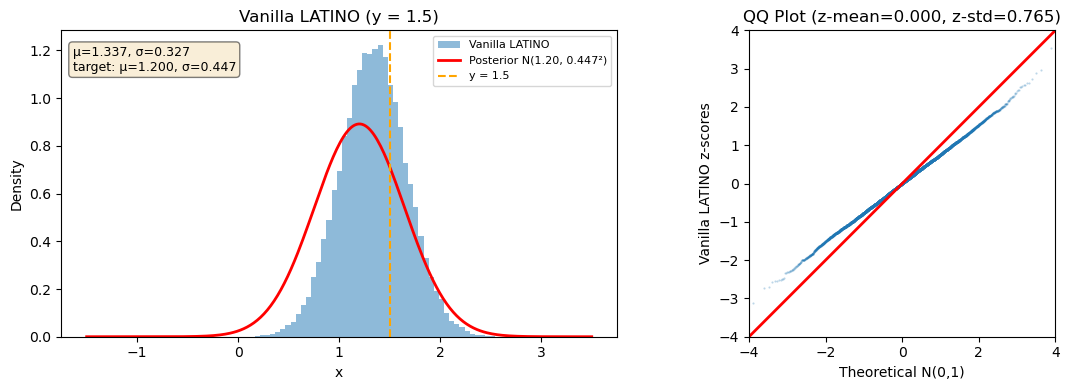

In [13]:
def latino(y, key, N=64, sigma_max=2.0, sigma_min=0.01):
    sigma_schedule = jnp.geomspace(sigma_max, sigma_min, N)
    x = y
    for k in range(N):
        sigma_k = sigma_schedule[k]
        key, subkey = jax.random.split(key)
        x_noisy = x + sigma_k * jax.random.normal(subkey, x.shape)
        u = pf_ode_denoise(x_noisy, sigma_k)
        delta_k = float(sigma_k)**2
        x = (delta_k * y + sigma_n**2 * u) / (delta_k + sigma_n**2)
    return x

res_latino = evaluate(latino, 'Vanilla LATINO', jax.random.PRNGKey(0))

## 2. DPS (Diffusion Posterior Sampling)

Run the full reverse SDE from noise, adding a likelihood gradient at each step.

DPS approximates $p(y|x_t) \approx \mathcal{N}(y \mid \hat{x}_0, \sigma_n^2)$, ignoring the Tweedie posterior covariance $V[x|x_t]$. This overestimates the guidance at large $\sigma_t$.

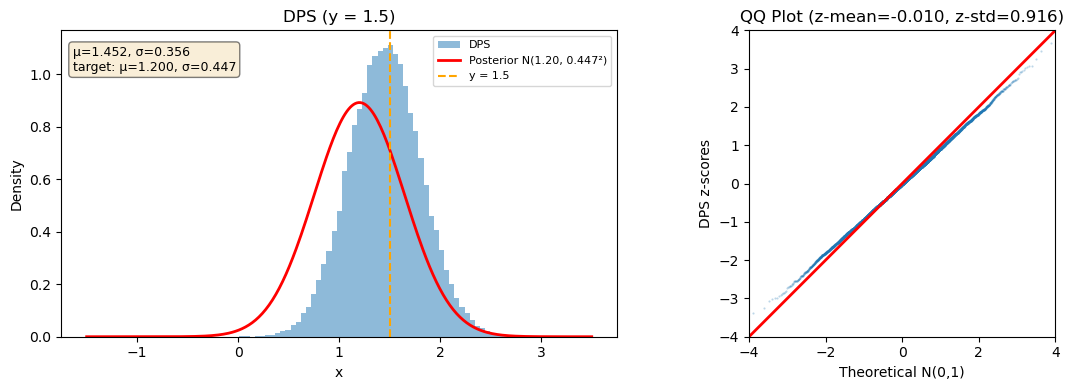

In [14]:
def dps(y, key, N=200, sigma_max=3.0, sigma_min=0.01, zeta=1.0):
    key, subkey = jax.random.split(key)
    x = mu_0 + jnp.sqrt(sigma_0**2 + sigma_max**2) * jax.random.normal(subkey, y.shape)

    log_R = jnp.log(sigma_max / sigma_min)
    dt = 1.0 / N

    for i in range(N):
        t = 1.0 - i * dt
        sigma_t = sigma_min * jnp.exp(log_R * t)
        key, subkey = jax.random.split(key)

        s = score_fn(x, sigma_t)
        x0_hat = x + sigma_t**2 * s  # Tweedie denoised estimate

        # Reverse SDE Euler-Maruyama step
        g2 = 2 * sigma_t**2 * log_R  # g²(t) = diffusion coeff squared
        x = x + g2 * s * dt
        x = x + sigma_t * jnp.sqrt(2 * log_R * dt) * jax.random.normal(subkey, x.shape)

        # DPS guidance: g²·dt · ∇_{x_t} log p(y|x_t)
        # with p(y|x_t) ≈ N(y | x̂₀, σ_n²)
        dx0_dx = sigma_0**2 / (sigma_0**2 + sigma_t**2)
        x = x + zeta * g2 * dt * (y - x0_hat) / sigma_n**2 * dx0_dx

    return x

res_dps = evaluate(dps, 'DPS', jax.random.PRNGKey(1))

## 3. MMPS (Moment-Matching Posterior Sampling)

Improves DPS by using the full Tweedie posterior moments:
$$p(y|x_t) \approx \mathcal{N}\bigl(y \mid \hat{x}_0(x_t),\; \sigma_n^2 + V[x|x_t]\bigr)$$

For Gaussian prior: $V[x|x_t] = \sigma_t^2 \sigma_0^2 / (\sigma_0^2 + \sigma_t^2)$ (via Tweedie's second identity).

**Key insight:** for the Gaussian case, this likelihood is *exact* (not an approximation), so MMPS with $\zeta=1$ should give perfectly calibrated posteriors.

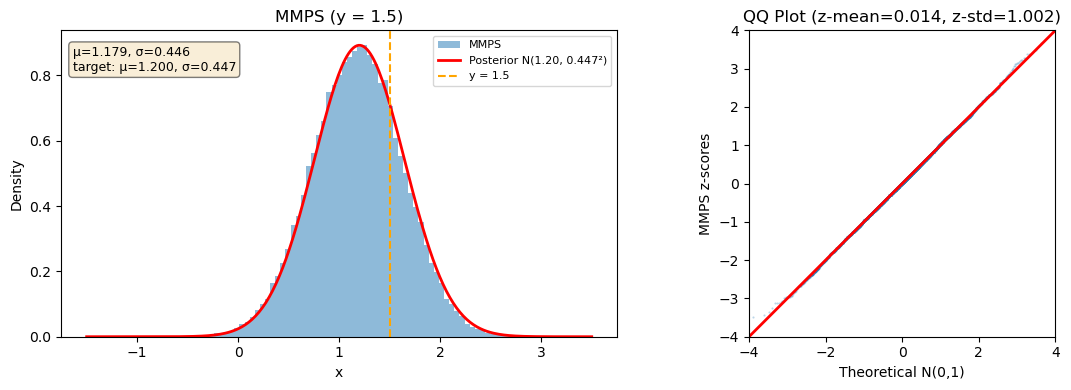

In [15]:
def mmps(y, key, N=200, sigma_max=3.0, sigma_min=0.01, zeta=1.0):
    key, subkey = jax.random.split(key)
    x = mu_0 + jnp.sqrt(sigma_0**2 + sigma_max**2) * jax.random.normal(subkey, y.shape)

    log_R = jnp.log(sigma_max / sigma_min)
    dt = 1.0 / N

    for i in range(N):
        t = 1.0 - i * dt
        sigma_t = sigma_min * jnp.exp(log_R * t)
        key, subkey = jax.random.split(key)

        s = score_fn(x, sigma_t)
        x0_hat = x + sigma_t**2 * s  # Tweedie mean

        # Tweedie covariance: V[x|x_t] = σ_t²σ_0²/(σ_0²+σ_t²)
        V_t = sigma_t**2 * sigma_0**2 / (sigma_0**2 + sigma_t**2)

        # Reverse SDE Euler-Maruyama step
        g2 = 2 * sigma_t**2 * log_R
        x = x + g2 * s * dt
        x = x + sigma_t * jnp.sqrt(2 * log_R * dt) * jax.random.normal(subkey, x.shape)

        # MMPS guidance: same as DPS but with σ_n² + V_t in denominator
        dx0_dx = sigma_0**2 / (sigma_0**2 + sigma_t**2)
        x = x + zeta * g2 * dt * (y - x0_hat) / (sigma_n**2 + V_t) * dx0_dx

    return x

res_mmps = evaluate(mmps, 'MMPS', jax.random.PRNGKey(3))

## 4. LATINO + Reverse SDE

Same structure as vanilla LATINO, but replace the deterministic PF-ODE denoiser with the stochastic reverse SDE.
The SDE injects additional noise during denoising, which could restore the missing variance.

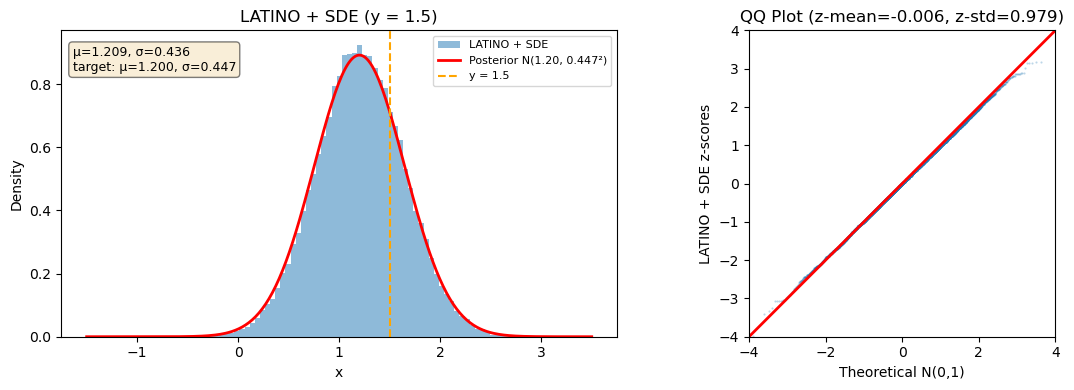

In [16]:
def latino_sde(y, key, N=64, sigma_max=2.0, sigma_min=0.01):
    sigma_schedule = jnp.geomspace(sigma_max, sigma_min, N)
    x = y
    for k in range(N):
        sigma_k = sigma_schedule[k]
        key, k1, k2 = jax.random.split(key, 3)
        x_noisy = x + sigma_k * jax.random.normal(k1, x.shape)
        u = sde_denoise(x_noisy, sigma_k, k2)  # stochastic denoiser
        delta_k = float(sigma_k)**2
        x = (delta_k * y + sigma_n**2 * u) / (delta_k + sigma_n**2)
    return x

res_sde = evaluate(latino_sde, 'LATINO + SDE', jax.random.PRNGKey(2))

In [17]:
# Summary comparison
mu_p = float(posterior_mean(y_star))
print(f"{'Method':<18} {'μ':>7} {'σ':>7} {'z-mean':>7} {'z-std':>7}")
print(f"{'Target':<18} {mu_p:7.3f} {sigma_post:7.3f} {'0.000':>7} {'1.000':>7}")
print("─" * 50)
for name, res in [('Vanilla LATINO', res_latino), ('DPS', res_dps),
                   ('MMPS', res_mmps), ('LATINO + SDE', res_sde)]:
    print(f"{name:<18} {res[0]:7.3f} {res[1]:7.3f} {res[2]:7.3f} {res[3]:7.3f}")

Method                   μ       σ  z-mean   z-std
Target               1.200   0.447   0.000   1.000
──────────────────────────────────────────────────
Vanilla LATINO       1.337   0.327   0.000   0.765
DPS                  1.452   0.356  -0.010   0.916
MMPS                 1.179   0.446   0.014   1.002
LATINO + SDE         1.209   0.436  -0.006   0.979
